# Model Tuning & Testing Notebook

Offline hyperparameter tuning and testing for XGBoost inference models.

**Approach:**
- Hold out `season ∈ {2025, 2026}` as a final test set
- CV on the remaining seasons: leave-one-season-out (LOSO) as target only
- Hyperparameter selection criterion: mean LOSO CV score
- Test-set metrics are final error estimates

Targets: `ev_atoi`, `pp_atoi`, `pk_atoi`, `gp_rate`, `evg60`, `eva60`, `ppg60`, `ppa60`

## Imports

In [79]:
import os, sys, time
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from tqdm.auto import tqdm

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [80]:
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
from feature_engineering import (
    ALL_TARGETS, FEATURE_SETS_XGB,
    build_modeling_frame, build_inference_frame, training_filter, compute_sample_weights,
)

## Setup

In [81]:
TEST_SEASONS = [2025, 2026]
PROJECTION_YEAR = 2027

In [82]:
frame = build_modeling_frame()
print('Frame dimensions:', frame.shape)

Frame dimensions: (14509, 65)


In [83]:
print('Rows per season\n\n', frame.groupby('season').size(), sep='')

Rows per season

season
2011     891
2012     894
2013     839
2014     886
2015     882
2016     898
2017     888
2018     890
2019     906
2020     883
2021     913
2022    1004
2023     951
2024     924
2025     920
2026     940
dtype: int64


In [84]:
frame

,playerId,skaterFullName,season,positionCode,ev_atoi,pp_atoi,pk_atoi,gp_rate,evg60,eva60,...,lag3_pp_toi_sec,lag3_pk_toi_sec,skaterFullName_bio,positionCode_bio,age,age2,age3,draft_round,draft_overall,is_rookie
0,8467875,Daniel Sedin,2011,L,14.838415,3.609950,0.104667,1.000000,1.134169,1.923156,...,20678.0,NaN,Daniel Sedin,L,30.012320,900.739372,27033.278550,1.0,2.0,0
1,8466378,Martin St. Louis,2011,R,15.999187,4.516867,0.463817,1.000000,1.234819,1.417755,...,20553.0,NaN,Martin St. Louis,R,35.288159,1245.254151,43942.726227,8.0,225.0,0
2,8470621,Corey Perry,2011,R,17.159553,3.508117,1.645317,1.000000,1.364525,1.279242,...,14628.0,NaN,Corey Perry,R,25.377139,643.999181,16342.856699,1.0,28.0,0
3,8467876,Henrik Sedin,2011,C,15.510976,3.595517,0.153033,1.000000,0.518909,2.264329,...,20703.0,NaN,Henrik Sedin,C,30.012320,900.739372,27033.278550,1.0,3.0,0
4,8474564,Steven Stamkos,2011,C,15.322967,4.547350,0.323983,1.000000,1.337065,1.289313,...,NaN,NaN,Steven Stamkos,C,20.646133,426.262799,8800.678350,1.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14504,8484821,Sam Morton,2026,C,8.038889,0.044433,1.250000,0.036585,0.000000,0.000000,...,NaN,NaN,Sam Morton,C,26.179329,685.357279,17942.193838,8.0,225.0,0
14505,8485251,Kai Uchacz,2026,C,11.516667,0.405550,0.261100,0.036585,0.000000,0.000000,...,NaN,NaN,Kai Uchacz,C,22.272416,496.060521,11048.466368,8.0,225.0,1
14506,8485385,Braeden Cootes,2026,C,9.638889,1.138883,0.000000,0.036585,0.000000,0.000000,...,NaN,NaN,Braeden Cootes,C,18.642026,347.525134,6478.572582,1.0,15.0,1
14507,8486166,Viking Gustafsson Nyberg,2026,D,17.066667,0.000000,4.225000,0.024390,0.000000,0.000000,...,NaN,NaN,Viking Gustafsson Nyberg,D,22.028747,485.265713,10689.795840,8.0,225.0,1


In [85]:
frame.columns

Index(['playerId', 'skaterFullName', 'season', 'positionCode', 'ev_atoi',
       'pp_atoi', 'pk_atoi', 'gp_rate', 'evg60', 'eva60', 'ppg60', 'ppa60',
       'gp', 'ev_toi_sec', 'pp_toi_sec', 'pk_toi_sec', 'is_defense',
       'is_forward', 'lag1_gp', 'lag1_gp_rate', 'lag1_all_atoi',
       'lag1_ev_atoi', 'lag1_pp_atoi', 'lag1_pk_atoi', 'lag1_evg60',
       'lag1_eva60', 'lag1_ppg60', 'lag1_ppa60', 'lag1_ev_toi_sec',
       'lag1_pp_toi_sec', 'lag1_pk_toi_sec', 'lag2_gp', 'lag2_gp_rate',
       'lag2_all_atoi', 'lag2_ev_atoi', 'lag2_pp_atoi', 'lag2_pk_atoi',
       'lag2_evg60', 'lag2_eva60', 'lag2_ppg60', 'lag2_ppa60',
       'lag2_ev_toi_sec', 'lag2_pp_toi_sec', 'lag2_pk_toi_sec', 'lag3_gp',
       'lag3_gp_rate', 'lag3_all_atoi', 'lag3_ev_atoi', 'lag3_pp_atoi',
       'lag3_pk_atoi', 'lag3_evg60', 'lag3_eva60', 'lag3_ppg60', 'lag3_ppa60',
       'lag3_ev_toi_sec', 'lag3_pp_toi_sec', 'lag3_pk_toi_sec',
       'skaterFullName_bio', 'positionCode_bio', 'age', 'age2', 'age3',
       'dr

## Definitions

In [86]:
DEFAULT_XGB_PARAMS = dict(
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    tree_method='hist', objective='reg:squarederror', n_jobs=4, verbosity=0,
)

In [87]:
# Fit XGB regressgor on train_sub for given target and hyperparams
def fit_xgb(target, train_sub, hp):
    feats = FEATURE_SETS_XGB[target]
    X = train_sub[feats].values
    y = train_sub[target].astype(float).values
    w = compute_sample_weights(train_sub, target, hp['decay'], PROJECTION_YEAR)
    params = {
        **DEFAULT_XGB_PARAMS,
        'n_estimators': hp.get('n_estimators', 200),
        'max_depth': hp.get('max_depth', 3),
        'learning_rate': hp.get('learning_rate', 0.05),
        'reg_lambda': hp.get('reg_lambda', 1.0),
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X, y, sample_weight=w)
    return model

In [88]:
# Predict with fitted XGB model on eval_sub for given target
def predict_xgb(model, target, eval_sub):
    feats = FEATURE_SETS_XGB[target]
    return model.predict(eval_sub[feats].values)

In [89]:
# Compute error metrics between true and predicted target values
def metrics(y_true, y_pred):
    err = y_true - y_pred
    return {
        'mae':  float(np.mean(np.abs(err))),
        'rmse': float(np.sqrt(np.mean(err ** 2))),
        'r2':   float(1 - np.var(err) / max(np.var(y_true), 1e-9)),
    }

In [90]:
# LOSO CV. Returns list of (season, rmse) tuples, one per held-out fold.
def cv_fold_scores(target, train_frame, hp):
    seasons = sorted(train_frame['season'].unique())
    fold_scores = []
    for held in seasons:
        tr = train_frame[train_frame['season'] != held]
        ev = train_frame[train_frame['season'] == held]
        ev = ev[training_filter(ev, target)]
        if ev.empty or tr.empty:
            continue
        model = fit_xgb(target, tr, hp)
        preds = predict_xgb(model, target, ev)
        rmse = metrics(ev[target].astype(float).values, preds)['rmse']
        fold_scores.append((held, rmse))
    return fold_scores

In [91]:
# Train on train_frame, predict on test_frame. Return metrics and predictions df
def held_out_test(target, hp, train_frame, test_frame):
    feats = FEATURE_SETS_XGB[target]
    test_filt = test_frame[training_filter(test_frame, target)].copy()
    model = fit_xgb(target, train_frame, hp)
    preds = predict_xgb(model, target, test_filt)
    y_true = test_filt[target].astype(float).values
    m = metrics(y_true, preds)

    meta_cols = ['playerId', 'skaterFullName', 'season', 'positionCode', 'age']
    available_meta = [c for c in meta_cols if c in test_filt.columns]
    pred_df = test_filt[available_meta + [f for f in feats if f not in available_meta]].copy()
    pred_df[f'{target}_true'] = y_true
    pred_df[f'{target}_pred'] = preds
    pred_df[f'{target}_error'] = y_true - preds
    pred_df[f'{target}_abs_error'] = np.abs(pred_df[f'{target}_error'])
    pred_df = pred_df.sort_values(f'{target}_abs_error', ascending=False).reset_index(drop=True)

    return m, pred_df

## Tuning Loop

Optuna TPE search over XGBoost hyperparams. Objective is the mean LOSO CV RMSE on pre-test seasons; selection criterion is `study.best_trial`. One study per target. No pruning — every trial runs the full LOSO sweep so trials are compared on equal footing across heterogeneous seasons.

In [92]:
N_TRIALS   = 60
OPTUNA_SEED = 42
LOG_FILE    = 'tuning_log.txt'

def suggest_hp(trial):
    return {
        'n_estimators':  trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth':     trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 1e-2, 2e-1, log=True),
        'decay':         trial.suggest_float('decay', 1e-3, 2e-1, log=True),
    }

In [93]:
print(f'Optuna budget: {N_TRIALS} trials per target ({N_TRIALS * len(ALL_TARGETS)} total trial fits)')

Optuna budget: 60 trials per target (480 total trial fits)


In [ ]:
W = 72
results = []

with open(LOG_FILE, 'w', buffering=1) as log_f:
    log_f.write(f"{'=' * W}\n")
    log_f.write(f"Optuna XGBoost Tuning  |  {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
    log_f.write(f"Targets  : {', '.join(ALL_TARGETS)}\n")
    log_f.write(f"N_TRIALS : {N_TRIALS} per target ({N_TRIALS * len(ALL_TARGETS)} total)  |  seed={OPTUNA_SEED}\n")
    log_f.write(f"{'=' * W}\n\n")

    total_bar = tqdm(
        total=N_TRIALS * len(ALL_TARGETS),
        unit='trial',
        bar_format='{desc}  {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]  {postfix}',
    )

    for t_idx, target in enumerate(ALL_TARGETS):
        base       = frame[training_filter(frame, target)]
        train_pool = base[~base['season'].isin(TEST_SEASONS)]
        test_pool  = base[base['season'].isin(TEST_SEASONS)]

        total_bar.set_description(f'[{t_idx+1}/{len(ALL_TARGETS)}] {target:<8}')
        total_bar.set_postfix({'trial': f'0/{N_TRIALS}', 'cv': '\u2014'}, refresh=True)

        sep = chr(0x2500) * W
        log_f.write(f"{sep}\n")
        log_f.write(f"[{t_idx+1}/{len(ALL_TARGETS)}] {target}  |  started {time.strftime('%H:%M:%S')}\n")
        log_f.write(f"{sep}\n")

        t0      = time.time()
        sampler = optuna.samplers.TPESampler(seed=OPTUNA_SEED)
        study   = optuna.create_study(direction='minimize', sampler=sampler,
                                      study_name=f'xgb_{target}')

        def objective(trial,
                      _target=target, _train_pool=train_pool,
                      _log_f=log_f, _bar=total_bar, _t_idx=t_idx):
            hp          = suggest_hp(trial)
            fold_scores = cv_fold_scores(_target, _train_pool, hp)
            if not fold_scores:
                raise optuna.TrialPruned()
            rmses   = [s for _, s in fold_scores]
            cv_mean = float(np.mean(rmses))
            cv_std  = float(np.std(rmses))
            trial.set_user_attr('fold_scores', fold_scores)
            trial.set_user_attr('cv_std', cv_std)
            _log_f.write(
                f"  {trial.number+1:3d}/{N_TRIALS}"
                f"  n_est={hp['n_estimators']:3d}  depth={hp['max_depth']}"
                f"  lr={hp['learning_rate']:.4f}  decay={hp['decay']:.4f}"
                f"  cv_rmse={cv_mean:.4f} \xb1{cv_std:.4f}\n"
            )
            _bar.set_postfix({'trial': f'{trial.number+1}/{N_TRIALS}', 'cv': f'{cv_mean:.4f}'}, refresh=True)
            _bar.update(1)
            return cv_mean

        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

        best_hp  = study.best_params
        best_cv  = study.best_value
        best_std = study.best_trial.user_attrs.get('cv_std', float('nan'))

        test_metrics, _ = held_out_test(target, best_hp, train_pool, test_pool)
        elapsed = time.time() - t0

        total_bar.set_postfix({
            'trial': f'{N_TRIALS}/{N_TRIALS}',
            'best_cv': f'{best_cv:.4f}',
            'test': f'{test_metrics["rmse"]:.4f}',
        }, refresh=True)

        log_f.write(
            f"\n  Best  trial {study.best_trial.number+1:3d}"
            f"  n_est={best_hp['n_estimators']:3d}  depth={best_hp['max_depth']}"
            f"  lr={best_hp['learning_rate']:.4f}  decay={best_hp['decay']:.4f}\n"
            f"  CV RMSE   {best_cv:.4f} \xb1{best_std:.4f}\n"
            f"  Test RMSE {test_metrics['rmse']:.4f}"
            f"  MAE {test_metrics['mae']:.4f}  R\xb2 {test_metrics['r2']:.4f}\n"
            f"  Elapsed   {elapsed:.1f}s\n\n"
        )

        results.append({
            'target':    target,
            'best_hp':   best_hp,
            'cv_rmse':   best_cv,
            'cv_std':    best_std,
            'test_rmse': test_metrics['rmse'],
            'test_mae':  test_metrics['mae'],
            'test_r2':   test_metrics['r2'],
            'study':     study,
        })

    total_bar.set_description('Done')
    total_bar.close()

    log_f.write(f"{'=' * W}\n")
    log_f.write(f"All targets complete  |  {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
    log_f.write(f"{'=' * W}\n")

results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'study'} for r in results])
results_df







































































































































[W 2026-04-28 01:12:23,213] Trial 4 failed with parameters: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.03647316284911211, 'decay': 0.004678719265016202} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/x7/l4fzcmr5641_9hgkws623m3r0000gn/T/ipykernel_89085/3751172811.py", line 39, in objective
    fold_scores = cv_fold_scores(_target, _train_pool, hp)
  File "/var/folders/x7/l4fzcmr5641_9hgkws623m3r0000gn/T/ipykernel_89085/2194536471.py", line 11, in cv_fold_scores
    model = fit_xgb(target, tr, hp)
  File "/var/folders/x7/l4fzcmr5641_9hgkws623m3r0000gn/T/ipykernel_89085/16106161.py", line 14, in fit_xgb
    model.

KeyboardInterrupt: 

In [95]:
INSPECT_TARGET = ALL_TARGETS[0]
study_for_target = next(r['study'] for r in results if r['target'] == INSPECT_TARGET)
trials_df = study_for_target.trials_dataframe(attrs=('number', 'value', 'params', 'user_attrs'))
trials_df.sort_values('value').head(10)

,number,value,params_decay,params_learning_rate,params_max_depth,params_n_estimators,user_attrs_cv_std,user_attrs_fold_scores
36,36,1.466714,0.012052,0.021731,6,250,0.100545,"[(2011, 1.6579609971581246), (2012, 1.69074252..."
37,37,1.466854,0.012229,0.014129,5,350,0.100479,"[(2011, 1.656758702275286), (2012, 1.690166621..."
32,32,1.467283,0.012493,0.017778,6,250,0.097469,"[(2011, 1.6556031205246977), (2012, 1.68934455..."
52,52,1.467559,0.003273,0.019119,5,250,0.099868,"[(2011, 1.6570358852898803), (2012, 1.69144958..."
39,39,1.467589,0.007926,0.011737,5,400,0.098735,"[(2011, 1.6516605894302627), (2012, 1.68992456..."
44,44,1.467696,0.005253,0.015053,5,350,0.099657,"[(2011, 1.6538419767493882), (2012, 1.68980407..."
53,53,1.467894,0.002906,0.018638,5,300,0.100697,"[(2011, 1.6596379383397966), (2012, 1.68972004..."
12,12,1.468062,0.005952,0.021203,5,250,0.099639,"[(2011, 1.6548612346184846), (2012, 1.68859673..."
45,45,1.468387,0.011351,0.014672,5,450,0.101437,"[(2011, 1.6626965448922877), (2012, 1.68858219..."
38,38,1.468418,0.022226,0.013924,5,400,0.100815,"[(2011, 1.657896899506684), (2012, 1.690173322..."


## `MODEL_CONFIG` block

Copy-paste into `model_training.py`.

In [96]:
lines = ["MODEL_CONFIG = {"]
for r in results:
    hp = r['best_hp']
    xgb_p = {k: hp[k] for k in ('n_estimators', 'max_depth', 'learning_rate')}
    lines.append(f"    '{r['target']}': {{'decay': {hp['decay']}, 'xgb_params': {xgb_p}}},")
lines.append('}')
print('\n'.join(lines))

MODEL_CONFIG = {
    'ev_atoi': {'decay': 0.01205196955951262, 'xgb_params': {'n_estimators': 250, 'max_depth': 6, 'learning_rate': 0.02173084201090787}},
}


---
## Testing

Evaluates a specific XGBoost configuration and outputs the following:
- Per-fold CV scores
- Mean CV score
- Test-set score (retrained on full train set)
- Predictions dataframe with features, true values, and errors

### Configuration

In [116]:
TEST_TARGET = 'evg60'
TEST_HP = {
    'n_estimators': 250,
    'max_depth': 6,
    'learning_rate': 0.02,
    'decay': 0.01,
    'reg_lambda': 0.10,
}

### Per-fold CV scores

In [117]:
base = frame[training_filter(frame, TEST_TARGET)]
train_pool = base[~base['season'].isin(TEST_SEASONS)]
test_pool  = base[base['season'].isin(TEST_SEASONS)]

fold_scores = cv_fold_scores(TEST_TARGET, train_pool, TEST_HP)

fold_df = pd.DataFrame(fold_scores, columns=['season', 'rmse'])
print(f'Target: {TEST_TARGET}')
print(fold_df.to_string(index=False))
print(f'\nMean CV RMSE: {fold_df["rmse"].mean():.4f}')
print(f'Std  CV RMSE: {fold_df["rmse"].std():.4f}')

Target: evg60
 season     rmse
   2011 0.220634
   2012 0.232529
   2013 0.253313
   2014 0.234746
   2015 0.235549
   2016 0.230004
   2017 0.250743
   2018 0.227066
   2019 0.247097
   2020 0.244621
   2021 0.269944
   2022 0.260045
   2023 0.256494
   2024 0.249736

Mean CV RMSE: 0.2438
Std  CV RMSE: 0.0141


### Test-set evaluation (retrained on full train set)

In [118]:
test_m, pred_df = held_out_test(TEST_TARGET, TEST_HP, train_pool, test_pool)

print(f'Target: {TEST_TARGET} | Test seasons: {TEST_SEASONS}')
print(f'  RMSE: {test_m["rmse"]:.4f}')
print(f'  MAE:  {test_m["mae"]:.4f}')
print(f'  R²:   {test_m["r2"]:.4f}')
print(f'  N:    {len(pred_df)}')

Target: evg60 | Test seasons: [2025, 2026]
  RMSE: 0.2422
  MAE:  0.1825
  R²:   0.5960
  N:    1427


### Test predictions

In [119]:
pred_df

,playerId,skaterFullName,season,positionCode,age,is_defense,draft_round,draft_overall,lag1_evg60,lag2_evg60,lag3_evg60,lag1_ev_atoi,lag1_eva60,lag1_ev_toi_sec,evg60_true,evg60_pred,evg60_error,evg60_abs_error
0,8473419,Brad Marchand,2026,L,37.390828,0,3.0,71.0,1.098454,0.991937,0.724383,13.847887,1.159479,58992.0,1.865147,0.767193,1.097954,1.097954
1,8471214,Alex Ovechkin,2025,L,39.039014,0,1.0,1.0,0.932267,1.487537,1.627174,14.664135,0.984059,69508.0,2.042862,1.035972,1.006890,1.006890
2,8480448,Parker Kelly,2026,C,26.384668,0,8.0,225.0,0.487635,0.478289,0.132602,10.766250,0.696621,51678.0,1.386989,0.488934,0.898055,0.898055
3,8481540,Cole Caufield,2026,R,24.744695,0,1.0,15.0,1.319469,0.878342,1.677169,14.972764,1.270600,73666.0,2.001056,1.129111,0.871945,0.871945
4,8483445,Cutter Gauthier,2026,L,21.700205,0,1.0,5.0,1.053008,0.000000,NaN,12.507723,1.170009,61538.0,1.675198,0.809228,0.865970,0.865970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1422,8475786,Zach Hyman,2025,L,32.312115,0,5.0,123.0,1.806462,0.992100,1.084322,16.191875,0.833751,77721.0,1.096685,1.097945,-0.001260,0.001260
1423,8475745,Charlie Coyle,2026,C,33.582478,0,1.0,28.0,0.712708,0.902668,0.798876,13.185743,0.767532,65665.0,0.679443,0.678405,0.001038,0.001038
1424,8482113,Anton Lundell,2026,C,23.994524,0,1.0,12.0,0.737554,0.711920,0.641952,13.386709,1.361638,63453.0,0.783673,0.782749,0.000925,0.000925
1425,8474716,Jared Spurgeon,2026,D,35.838467,1,6.0,156.0,0.304685,0.000000,0.431127,17.902273,0.863273,70893.0,0.185526,0.184661,0.000865,0.000865


In [120]:
pred_df.columns

Index(['playerId', 'skaterFullName', 'season', 'positionCode', 'age',
       'is_defense', 'draft_round', 'draft_overall', 'lag1_evg60',
       'lag2_evg60', 'lag3_evg60', 'lag1_ev_atoi', 'lag1_eva60',
       'lag1_ev_toi_sec', 'evg60_true', 'evg60_pred', 'evg60_error',
       'evg60_abs_error'],
      dtype='object')

In [121]:
pred_df[['playerId', 'skaterFullName', 'season', 'positionCode', 'age',
          f'lag1_{TEST_TARGET}', f'lag2_{TEST_TARGET}', f'lag3_{TEST_TARGET}',
          f'{TEST_TARGET}_true', f'{TEST_TARGET}_pred', f'{TEST_TARGET}_error']].head(25)

,playerId,skaterFullName,season,positionCode,age,lag1_evg60,lag2_evg60,lag3_evg60,evg60_true,evg60_pred,evg60_error
0,8473419,Brad Marchand,2026,L,37.390828,1.098454,0.991937,0.724383,1.865147,0.767193,1.097954
1,8471214,Alex Ovechkin,2025,L,39.039014,0.932267,1.487537,1.627174,2.042862,1.035972,1.006890
2,8480448,Parker Kelly,2026,C,26.384668,0.487635,0.478289,0.132602,1.386989,0.488934,0.898055
3,8481540,Cole Caufield,2026,R,24.744695,1.319469,0.878342,1.677169,2.001056,1.129111,0.871945
4,8483445,Cutter Gauthier,2026,L,21.700205,1.053008,0.000000,NaN,1.675198,0.809228,0.865970
5,8481656,Aliaksei Protas,2025,L,23.734428,0.364883,0.369307,0.503332,1.445396,0.597251,0.848145
6,8482699,Dylan Guenther,2026,R,22.477755,0.958381,0.862198,0.326264,1.696693,0.853558,0.843135
7,8477511,Anthony Mantha,2026,R,31.041752,0.774943,1.289722,0.672709,1.495375,0.690809,0.804565
8,8477380,Jonny Brodzinski,2025,C,31.285421,0.510609,0.394694,0.274140,1.287592,0.484003,0.803589
9,8479987,Morgan Geekie,2025,C,26.201232,0.758816,0.725130,0.514580,1.497676,0.694638,0.803038


In [122]:
pred_df[[f'{TEST_TARGET}_true', f'{TEST_TARGET}_pred',
         f'{TEST_TARGET}_error', f'{TEST_TARGET}_abs_error']].describe()

,evg60_true,evg60_pred,evg60_error,evg60_abs_error
count,1427.000000,1427.000000,1427.000000,1427.000000
mean,0.542607,0.542805,-0.000198,0.182527
std,0.381241,0.292877,0.242314,0.159301
min,0.000000,0.097335,-0.785200,0.000417
25%,0.226649,0.224464,-0.147717,0.066405
50%,0.495011,0.589707,-0.013387,0.137870
75%,0.795257,0.748080,0.119622,0.254868
max,2.042862,1.389581,1.097954,1.097954


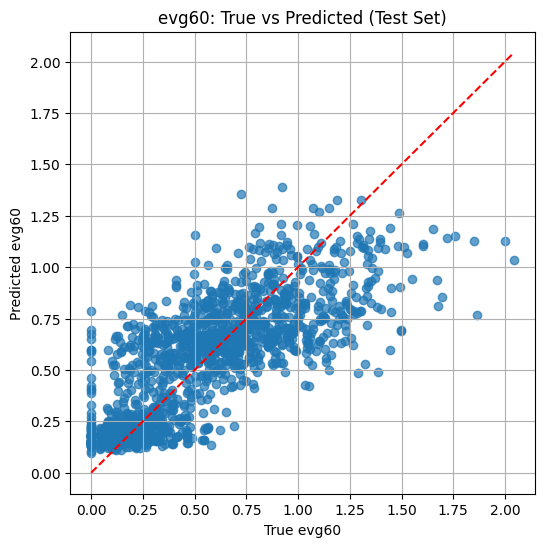

In [123]:
# scatter of true vs predicted target
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))
plt.scatter(pred_df[f'{TEST_TARGET}_true'], pred_df[f'{TEST_TARGET}_pred'], alpha=0.7)
plt.plot([0, pred_df[f'{TEST_TARGET}_true'].max()], [0, pred_df[f'{TEST_TARGET}_true'].max()], 'r--')
plt.xlabel(f'True {TEST_TARGET}')
plt.ylabel(f'Predicted {TEST_TARGET}')
plt.title(f'{TEST_TARGET}: True vs Predicted (Test Set)')
plt.grid(True)
plt.show()

In [124]:
# break true evg60 into 10% quantiles and look at error stats within each bin
pred_df['true_bin'] = pd.qcut(pred_df[f'{TEST_TARGET}_true'], q=10, duplicates='drop')
bin_stats = pred_df.groupby('true_bin')[[f'{TEST_TARGET}_error', f'{TEST_TARGET}_abs_error']].agg(['mean', 'std', 'count'])
bin_stats.columns = ['_'.join(col) for col in bin_stats.columns]
bin_stats = bin_stats.reset_index()
bin_stats

,true_bin,evg60_error_mean,evg60_error_std,evg60_error_count,evg60_abs_error_mean,evg60_abs_error_std,evg60_abs_error_count
0,"(-0.001, 0.1]",-0.182948,0.139517,143,0.182948,0.139517,143
1,"(0.1, 0.183]",-0.106593,0.149297,143,0.111227,0.145853,143
2,"(0.183, 0.265]",-0.076203,0.185123,142,0.132521,0.149774,142
3,"(0.265, 0.364]",-0.078470,0.200540,143,0.170619,0.130773,143
4,"(0.364, 0.495]",-0.069507,0.203822,143,0.188925,0.102295,143
5,"(0.495, 0.61]",-0.078854,0.192145,142,0.164609,0.126068,142
6,"(0.61, 0.734]",-0.008358,0.160363,143,0.121361,0.104663,143
7,"(0.734, 0.88]",0.040494,0.165374,142,0.137673,0.099558,142
8,"(0.88, 1.075]",0.166707,0.193899,143,0.215788,0.136717,143
9,"(1.075, 2.043]",0.390955,0.230461,143,0.398806,0.216492,143


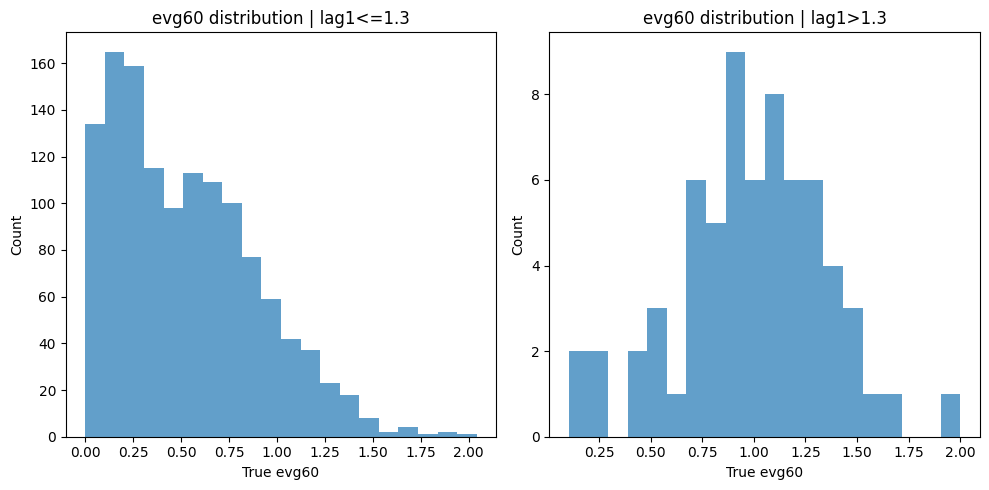

In [125]:
pred_df['lag1_bin'] = pd.cut(
    pred_df[f'lag1_{TEST_TARGET}'],
    bins=[-np.inf, 1.3, np.inf],
    labels=['lag1<=1.3', 'lag1>1.3']
)

plt.figure(figsize=(10, 5))
for i, lag1_bin in enumerate(pred_df['lag1_bin'].cat.categories):
    subset = pred_df[pred_df['lag1_bin'] == lag1_bin]
    plt.subplot(1, 2, i + 1)
    plt.hist(subset[f'{TEST_TARGET}_true'], bins=20, alpha=0.7)
    plt.title(f'{TEST_TARGET} distribution | {lag1_bin}')
    plt.xlabel(f'True {TEST_TARGET}')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

### Future predictions

In [126]:
inference_frame = build_inference_frame(PROJECTION_YEAR)
inference_frame['skaterFullName'] = inference_frame['skaterFullName'].fillna(inference_frame['skaterFullName_bio'])

raw_seasons = build_modeling_frame()[['playerId', 'season']]
active_ids = raw_seasons.loc[raw_seasons['season'].isin([PROJECTION_YEAR - 1, PROJECTION_YEAR]), 'playerId'].unique()
inference_frame = inference_frame[inference_frame['playerId'].isin(active_ids)].reset_index(drop=True)

print(f'{PROJECTION_YEAR} inference frame: {inference_frame.shape[0]} candidates')
inference_frame[['playerId', 'skaterFullName', 'positionCode', 'age', f'lag1_{TEST_TARGET}', f'lag2_{TEST_TARGET}', f'lag3_{TEST_TARGET}']].head()

2027 inference frame: 940 candidates


,playerId,skaterFullName,positionCode,age,lag1_evg60,lag2_evg60,lag3_evg60
0,8470613,Brent Burns,D,41.563313,0.549178,0.259931,0.220794
1,8470621,Corey Perry,R,41.377139,0.881777,1.045418,0.868284
2,8471214,Alex Ovechkin,L,41.037645,1.526933,2.042862,0.932267
3,8471215,Evgeni Malkin,C,40.169747,1.113494,0.692974,1.014711
4,8471675,Sidney Crosby,C,39.151266,1.041429,0.918111,1.426802


In [127]:
full_pool = frame[training_filter(frame, TEST_TARGET)]
full_model = fit_xgb(TEST_TARGET, full_pool, TEST_HP)

future_preds = predict_xgb(full_model, TEST_TARGET, inference_frame)
future_df = inference_frame[['playerId', 'skaterFullName', 'positionCode', 'age', f'lag3_{TEST_TARGET}', f'lag2_{TEST_TARGET}', f'lag1_{TEST_TARGET}']].copy()
future_df[f'{TEST_TARGET}_pred'] = future_preds
future_df = future_df.sort_values(f'{TEST_TARGET}_pred', ascending=False).reset_index(drop=True)

print(f'Target: {TEST_TARGET} | Projection year: {PROJECTION_YEAR} | N={len(future_df)}')
future_df.head(25)

Target: evg60 | Projection year: 2027 | N=940


,playerId,skaterFullName,positionCode,age,lag3_evg60,lag2_evg60,lag1_evg60,evg60_pred
0,8479420,Tage Thompson,C,28.919918,1.048221,1.852006,1.605435,1.307818
1,8476453,Nikita Kucherov,R,33.289528,1.303449,1.285651,1.719385,1.303631
2,8484801,Macklin Celebrini,C,20.301164,NaN,0.885750,1.550117,1.302375
3,8477492,Nathan MacKinnon,C,31.082820,1.643964,0.924468,1.757506,1.294387
4,8478398,Kyle Connor,L,29.809719,1.648274,1.309837,1.349215,1.236496
5,8479542,Brandon Hagel,L,28.095825,1.093616,1.445130,1.653247,1.231800
6,8477956,David Pastrnak,R,30.351814,1.588843,1.488816,0.872427,1.227098
7,8477960,Adrian Kempe,R,30.047912,1.101895,1.336174,1.510126,1.225681
8,8479318,Auston Matthews,C,29.037645,2.242634,1.185622,1.304219,1.217078
9,8477939,William Nylander,R,30.417522,1.224137,1.483794,1.284717,1.202375
